In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import backtestPairs, calculatePairMetrics
# from MODELS.teamInfo import *


In [2]:
import joblib


# Load NGBoost mean and variance models
mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_TEST_25.pkl')
variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_TEST_25.pkl')
calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_TEST_25.pkl')

# mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_TEST_26.pkl')
# variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_TEST_26.pkl')
# calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_TEST_26.pkl')

models = {
    'mean': mean_model,
    'variance': variance_model,
    'calibration_factor': calibration_factor
}

features = joblib.load('../MODELS/SAVED_MODELS/feature_list.pkl')

print(f"Loaded NGBoost models with calibration factor: {calibration_factor}")
print(f"Number of features: {len(features)}")

Loaded NGBoost models with calibration factor: 3.97
Number of features: 147


In [3]:
pd.set_option('display.max_columns', None)

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
# s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
# s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')
# df = s26
df = s25

In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'prizepicks') &  (backtestData['CATEGORY'] == 'player_points')]
backtestData.sample(5)


C:\Users\alexg\AppData\Local\Temp\ipykernel_22572\2718787215.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
194642,194642,194642,115221,Devin Booker,player_points,prizepicks,under,24.5,-137,Phoenix Suns,San Antonio Spurs,NaN,NaN,2025-04-12,game,28.5,-642.0,under
153220,153220,153220,62527,Jeremy Sochan,player_points,prizepicks,over,15.5,-137,Toronto Raptors,San Antonio Spurs,NaN,NaN,2025-03-23,game,12.5,-108.0,over
130861,130861,130861,33774,Ausar Thompson,player_points,prizepicks,under,10.5,-137,Detroit Pistons,Washington Wizards,NaN,NaN,2025-03-13,game,10.5,104.0,under
12775,12775,12775,12775,Dyson Daniels,player_points,prizepicks,under,14.0,-137,Boston Celtics,Atlanta Hawks,74058cb479045efa21ebd5c57050e23e,2024-11-13T00:10:00Z,2024-11-12,NaN,NaN,NaN,under
57822,57822,57822,57822,Andre Jackson Jr,player_points,prizepicks,under,4.5,-137,Milwaukee Bucks,Memphis Grizzlies,NaN,NaN,2025-02-03,game,4.5,-118.0,under


In [95]:
# backtestData= pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/s26props.csv')
# s26_other = pd.read_csv('../DATA/CSV_FILES/PROP_DATA/PLAYER_LINES/NBA_DFS_20251106.csv')
# s26_other1 = pd.read_csv('../DATA/CSV_FILES/PROP_DATA/PLAYER_LINES/NBA_DFS_20251107.csv')
# backtestData = pd.concat([backtestData, s26_other, s26_other1])

# backtestData = backtestData[(backtestData['BOOKMAKER'] == 'Underdog') &  
#                             (backtestData['CATEGORY'] == 'player_points')]
# backtestData.rename(columns={'COMMENCE_TIME': 'GAME_DATE', 'OVER/UNDER': 'SIDE'}, inplace=True)
# backtestData

In [7]:
date = '2024-11-06'

results = backtestPairs(
    data=s25,
    backtestData=backtestData,
    gameDate=date,
    models=models,  
    features=features,
    edge_threshold=4.5, 
    top_n=15, 
    variance_inflation=1.1, 
    use_monte_carlo=True, n_simulations=10000, max_kelly=0.25, stake=10, max_player_appearances=3)


# Comprehensive results analysis
if not results.empty:
    print("=" * 60)
    print("PAIR BETTING RESULTS ANALYSIS")
    print("=" * 60)
    
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Calculate profit/loss
    total_profit = results['pair_profit'].sum() * 3
    avg_profit = results['pair_profit'].mean() * 3
    
    print(f"Total Bets: {total_bets}")
    print(f"Wins: {total_wins}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total Profit: ${total_profit:.2f}")
    print(f"Average Profit per Bet: ${avg_profit:.2f}")

results

Starting backtest for pairs on 2024-11-06
Applied player frequency limit (3 max appearances per player)
Selected 147 combinations from 4683 candidates
Time taken for pairs: 32.406941413879395 seconds
Time taken for sorting: 32.40794849395752 seconds
Time taken for dropping duplicates: 32.41095471382141 seconds
Time taken for iterating over evData: 32.41095471382141 seconds
Time taken for backtest_results: 32.421470642089844 seconds
PAIR BETTING RESULTS ANALYSIS
Total Bets: 15
Wins: 7
Win Rate: 46.67%
Total Profit: $180.00
Average Profit per Bet: $12.00


,NAME 1,NAME 2,LINE 1,LINE 2,PREDICTION 1,PREDICTION 2,MODEL SIDE 1,MODEL SIDE 2,PROB 1,PROB 2,PROB BOTH,EDGE 1,EDGE 2,COMBINED EDGE,EV$,KELLY FULL,RECOMMENDATION,INTERVAL WIDTH 1,INTERVAL WIDTH 2,SIGMA 1,SIGMA 2,SIGMA FLAG 1,SIGMA FLAG 2,EXPECTED ROI,SIMULATION METHOD,actual1,actual2,leg1_won,leg2_won,pair_won,pair_recommendation,pair_profit,selection,date
0,Brandon Miller,Tyrese Maxey,18.5,27.5,12.36,22.21,under,under,0.792,0.745,0.5899,0.214,0.167,0.256,7.70,0.385,1,26.26,30.87,7.09,7.87,High,High,77.0,Monte Carlo,19,12,0,1,0,1,-10.0,top_ev,2024-11-06
1,Brandon Miller,Paul George,18.5,21.5,12.36,16.27,under,under,0.792,0.742,0.5881,0.214,0.164,0.254,7.64,0.382,1,26.26,30.30,7.09,7.73,High,High,76.4,Monte Carlo,19,18,0,1,0,1,-10.0,top_ev,2024-11-06
2,Brandon Miller,Jalen Brunson,18.5,28.5,12.36,23.89,under,under,0.792,0.722,0.5719,0.214,0.144,0.238,7.16,0.358,1,26.26,29.52,7.09,7.53,High,High,71.6,Monte Carlo,19,21,0,1,0,1,-10.0,top_ev,2024-11-06
3,Jalen Brunson,Tyrese Maxey,28.5,27.5,23.89,22.21,under,under,0.723,0.745,0.5387,0.145,0.167,0.205,6.16,0.308,1,29.52,30.87,7.53,7.87,High,High,61.6,Monte Carlo,21,12,1,1,1,1,20.0,top_ev,2024-11-06
4,Jalen Brunson,Paul George,28.5,21.5,23.89,16.27,under,under,0.723,0.742,0.5371,0.145,0.164,0.203,6.11,0.306,1,29.52,30.30,7.53,7.73,High,High,61.1,Monte Carlo,21,18,1,1,1,1,20.0,top_ev,2024-11-06
5,Victor Wembanyama,Tyrese Maxey,24.0,27.5,19.32,22.21,under,under,0.720,0.745,0.5366,0.142,0.167,0.202,6.10,0.305,1,30.04,30.87,7.66,7.87,High,High,61.0,Monte Carlo,15,12,1,1,1,1,20.0,top_ev,2024-11-06
6,Victor Wembanyama,Paul George,24.0,21.5,19.32,16.27,under,under,0.720,0.742,0.5349,0.142,0.164,0.201,6.05,0.302,1,30.04,30.30,7.66,7.73,High,High,60.5,Monte Carlo,15,18,1,1,1,1,20.0,top_ev,2024-11-06
7,Zach Edey,Victor Wembanyama,10.0,24.0,13.16,19.32,over,under,0.713,0.721,0.5139,0.135,0.143,0.180,5.42,0.271,0,23.70,30.04,6.05,7.66,High,High,54.2,Monte Carlo,8,15,0,1,0,0,-10.0,top_ev,2024-11-06
8,Zach Edey,Kevin Durant,10.0,23.5,13.16,27.53,over,over,0.713,0.712,0.5077,0.135,0.134,0.174,5.23,0.261,0,23.70,28.51,6.05,7.27,High,High,52.3,Monte Carlo,8,32,0,1,0,0,-10.0,top_ev,2024-11-06
9,Dyson Daniels,Kevin Durant,9.0,23.5,12.19,27.53,over,over,0.712,0.712,0.5069,0.134,0.134,0.173,5.21,0.260,0,24.93,28.51,6.50,7.27,High,High,52.1,Monte Carlo,6,32,0,1,0,0,-10.0,top_ev,2024-11-06


## Points

In [9]:
uniqueDates = sorted(s25['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPairs(
        data=s25,
        backtestData=backtestData,
        gameDate=date,
        models=models,  
        features=features,
        edge_threshold=4.5, 
        top_n=10, 
        variance_inflation=1.1, 
        use_monte_carlo=False, n_simulations=10000, max_kelly=0.25, stake=10, max_player_appearances=5)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-22... 1/163
Starting backtest for pairs on 2024-10-22
Applied player frequency limit (5 max appearances per player)
Selected 70 combinations from 314 candidates
Time taken for pairs: 0.6957430839538574 seconds
Time taken for sorting: 0.6967413425445557 seconds
Time taken for dropping duplicates: 0.6982583999633789 seconds
Time taken for iterating over evData: 0.6982583999633789 seconds
Time taken for backtest_results: 0.705268144607544 seconds
  ✓ Processed 10 bets
Processing 2024-10-23... 2/163
Starting backtest for pairs on 2024-10-23
Applied player frequency limit (5 max appearances per player)
Selected 190 combinations from 2785 candidates
Time taken for pairs: 6.992002964019775 seconds
Time taken for sorting: 6.993004322052002 seconds
Time taken for dropping duplicates: 6.995013236999512 seconds
Time taken for iterating over evData: 6.995013236999512 seconds
Time taken for backtest_results: 7.001518964767456 seconds
  ✓ Processed 10 bets
Processing 2024-10-24...

KeyboardInterrupt: 

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,359
   Wins: 489
   Hit Rate: 35.98%
   Total Profit: $1,080.00
   Total Staked: $13,590.00
   ROI: 7.95%
   Volatility: $76.20
   Max Drawdown: $-720.00
   Sharpe Ratio: 1.991

   PROBABILITY METRICS:
   Brier Score: 0.2682 (lower is better)
   Log Loss: 0.7324 (lower is better)
   AUC-ROC: 0.5816 (higher is better)
   Samples: 1359


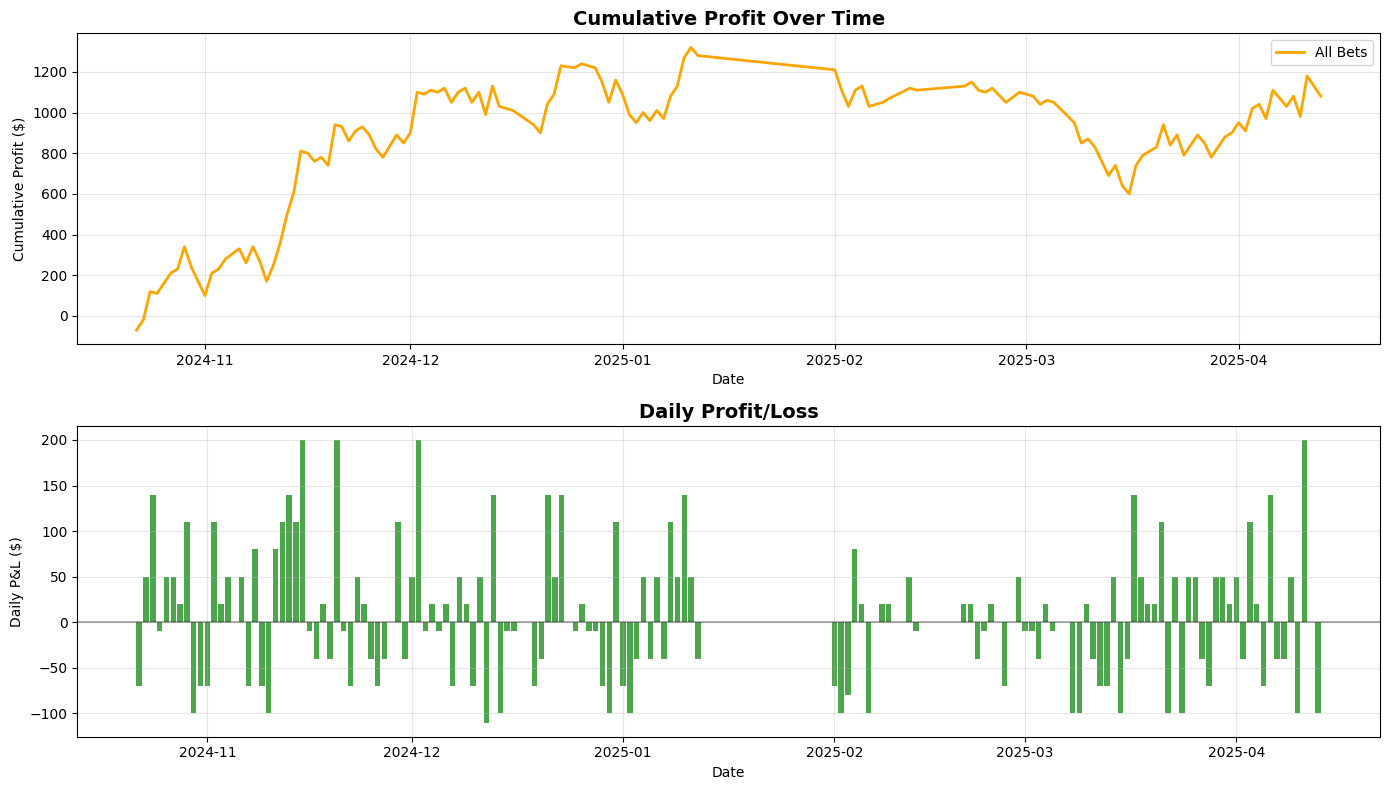

In [13]:
all_metrics = calculatePairMetrics(final_results, stake=10)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=10)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")
    
    # Display probability metrics
    if 'probability_metrics' in all_metrics and 'error' not in all_metrics['probability_metrics']:
        prob_metrics = all_metrics['probability_metrics']
        print(f"\n   PROBABILITY METRICS:")
        print(f"   Brier Score: {prob_metrics.get('brier_score', 'N/A'):.4f} (lower is better)")
        print(f"   Log Loss: {prob_metrics.get('log_loss', 'N/A'):.4f} (lower is better)")
        if not np.isnan(prob_metrics.get('auc_roc', np.nan)):
            print(f"   AUC-ROC: {prob_metrics.get('auc_roc', 'N/A'):.4f} (higher is better)")
        else:
            print(f"   AUC-ROC: NaN ({prob_metrics.get('auc_roc_note', 'Only one class present')})")
        print(f"   Samples: {prob_metrics.get('n_samples', 'N/A')}")

if rec_metrics:
    print("\n RECOMMENDED BETS ANALYSIS (Edge > 0.60):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")
    
# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()